# Fake News Classifier — DistilBERT Fine-Tuning
**Dataset:** LIAR (Wang, 2017) — 6-way truthfulness labels collapsed to binary fake/real  
**Model:** `distilbert-base-uncased` via HuggingFace Transformers  

Loads directly from the HuggingFace Hub — no manual data download needed.

## 1. Install / upgrade dependencies

In [2]:
!pip install -q --upgrade huggingface_hub transformers datasets accelerate

## 2. Imports & seeds

In [3]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


## 3. Paths & config

In [4]:
WORK_DIR  = Path('/kaggle/working')
MODEL_DIR = WORK_DIR / 'model'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 128   # LIAR statements avg ~17 words; 128 tokens is sufficient
USE_FP16   = torch.cuda.is_available()

## 4. Load & preprocess LIAR

**Setup:** Add the LIAR dataset via **Add Data** → search `liar dataset` on Kaggle (e.g. `uciml/liar-dataset` or similar).  
The TSV files have no header; column 1 is the 6-way label, column 2 is the statement.  

Binary collapse: {`false`, `barely-true`, `pants-fire`} → **FAKE (1)** | {`half-true`, `mostly-true`, `true`} → **REAL (0)**

In [8]:
import glob as _glob

# Find LIAR TSV files wherever Kaggle mounted them
_tsv_dirs = _glob.glob('/kaggle/input/datasets/doanquanvietnamca/liar-dataset') + _glob.glob('/kaggle/input/*LIAR*')
if not _tsv_dirs:
    raise FileNotFoundError('LIAR dataset not found — add it via Add Data in the Kaggle sidebar.')
LIAR_DIR = Path(_tsv_dirs[0])
print(f'Using LIAR data from: {LIAR_DIR}')

TSV_COLS = [
    'id', 'label', 'statement', 'subjects', 'speaker', 'job_title',
    'state_info', 'party', 'barely_true_ct', 'false_ct',
    'half_true_ct', 'mostly_true_ct', 'pants_fire_ct', 'context',
]
FAKE_LABELS = {'false', 'barely-true', 'pants-fire'}

def load_tsv(filename):
    df = pd.read_csv(
        LIAR_DIR / filename,
        sep='\t', header=None, names=TSV_COLS,
        dtype={'label': str},
    )
    df['text']  = df['statement'].fillna('')
    df['label'] = df['label'].apply(lambda x: 1 if x in FAKE_LABELS else 0)
    return df[['text', 'label']]

train_df = load_tsv('train.tsv')
val_df   = load_tsv('valid.tsv')
test_df  = load_tsv('test.tsv')

from datasets import Dataset as HFDataset
liar_train = HFDataset.from_pandas(train_df, preserve_index=False)
liar_val   = HFDataset.from_pandas(val_df,   preserve_index=False)
liar_test  = HFDataset.from_pandas(test_df,  preserve_index=False)

def print_distribution(name, ds):
    total = len(ds)
    fake  = sum(ds['label'])
    real  = total - fake
    print(f'\n{name} ({total} rows):')
    print(f'  REAL: {real} ({real/total*100:.1f}%)')
    print(f'  FAKE: {fake} ({fake/total*100:.1f}%)')

for name, ds in [('Train', liar_train), ('Val', liar_val), ('Test', liar_test)]:
    print_distribution(name, ds)

Using LIAR data from: /kaggle/input/datasets/doanquanvietnamca/liar-dataset

Train (10240 rows):
  REAL: 5752 (56.2%)
  FAKE: 4488 (43.8%)

Val (1284 rows):
  REAL: 668 (52.0%)
  FAKE: 616 (48.0%)

Test (1267 rows):
  REAL: 714 (56.4%)
  FAKE: 553 (43.6%)


## 5. Tokenize

In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH,
    )

train_ds = liar_train.map(tokenize, batched=True)
val_ds   = liar_val.map(tokenize,   batched=True)
test_ds  = liar_test.map(tokenize,  batched=True)

fmt_cols = ['input_ids', 'attention_mask', 'label']
train_ds.set_format(type='torch', columns=fmt_cols)
val_ds.set_format(type='torch',   columns=fmt_cols)
test_ds.set_format(type='torch',  columns=fmt_cols)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/10240 [00:00<?, ? examples/s]

Map:   0%|          | 0/1284 [00:00<?, ? examples/s]

Map:   0%|          | 0/1267 [00:00<?, ? examples/s]

Train: 10240 | Val: 1284 | Test: 1267


## 6. Train

In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    return {'accuracy': acc, 'f1': f1, 'precision': p, 'recall': r}

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

args = TrainingArguments(
    output_dir=str(MODEL_DIR),
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    fp16=USE_FP16,
    seed=SEED,
    logging_steps=50,
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super(

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.300479,1.304777,0.635514,0.628041,0.638788,0.630808
2,1.215524,1.323685,0.626168,0.607782,0.639752,0.618414
3,1.009339,1.420529,0.625389,0.607104,0.638669,0.617666
4,0.798131,1.564007,0.623832,0.617359,0.625435,0.619581
5,0.609658,1.703846,0.621495,0.614414,0.623384,0.617019


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1600, training_loss=1.003759949207306, metrics={'train_runtime': 385.3194, 'train_samples_per_second': 132.877, 'train_steps_per_second': 4.152, 'total_flos': 1695582702796800.0, 'train_loss': 1.003759949207306, 'epoch': 5.0})

## 7. Save model & tokenizer

In [11]:
trainer.save_model(str(MODEL_DIR))
tokenizer.save_pretrained(str(MODEL_DIR))
print(f'Model saved to {MODEL_DIR}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /kaggle/working/model


## 8. Evaluate — metrics & confusion matrix

In [12]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
eval_model = AutoModelForSequenceClassification.from_pretrained(str(MODEL_DIR)).to(DEVICE)
eval_model.eval()
eval_tokenizer = AutoTokenizer.from_pretrained(str(MODEL_DIR))

BATCH_SIZE = 32

def run_inference(texts):
    all_preds = []
    for i in range(0, len(texts), BATCH_SIZE):
        batch = list(texts[i : i + BATCH_SIZE])
        inputs = eval_tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=MAX_LENGTH,
            return_tensors='pt',
        ).to(DEVICE)
        with torch.no_grad():
            logits = eval_model(**inputs).logits
        all_preds.extend(logits.argmax(dim=-1).cpu().tolist())
    return all_preds

texts  = liar_test['text']
y_true = liar_test['label']

print(f'Running inference on {len(texts)} test samples...')
y_pred = run_inference(texts)

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

print(f'\nAccuracy:  {acc:.4f}')
print(f'Precision: {precision:.4f} (macro)')
print(f'Recall:    {recall:.4f} (macro)')
print(f'F1:        {f1:.4f} (macro)')
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=['REAL', 'FAKE']))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Running inference on 1267 test samples...

Accuracy:  0.6338
Precision: 0.6264 (macro)
Recall:    0.6153 (macro)
F1:        0.6146 (macro)

Classification Report:
              precision    recall  f1-score   support

        REAL       0.65      0.76      0.70       714
        FAKE       0.60      0.47      0.53       553

    accuracy                           0.63      1267
   macro avg       0.63      0.62      0.61      1267
weighted avg       0.63      0.63      0.63      1267



## 9. Confusion matrix

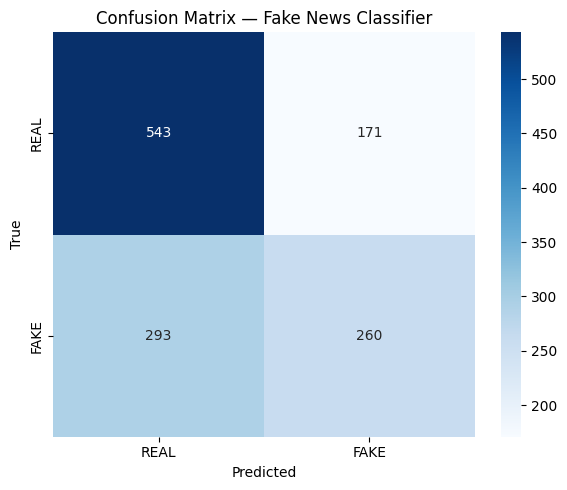

Saved confusion_matrix.png


In [13]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['REAL', 'FAKE'],
    yticklabels=['REAL', 'FAKE'],
    ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Fake News Classifier')
plt.tight_layout()
plt.savefig(WORK_DIR / 'confusion_matrix.png', dpi=150)
plt.show()
print('Saved confusion_matrix.png')

## 10. Quick predict() helper

In [14]:
def predict(text: str) -> str:
    """Return 'FAKE' or 'REAL' for a single input string."""
    pred = run_inference([text])[0]
    return 'FAKE' if pred == 1 else 'REAL'


# Quick sanity checks
samples = [
    'Scientists confirm mRNA vaccines are safe after 3-year follow-up study',
    'SHOCKING: Government secretly replacing water with mind control chemicals',
]
for s in samples:
    print(f'{predict(s):4s}  |  {s}')

FAKE  |  Scientists confirm mRNA vaccines are safe after 3-year follow-up study
FAKE  |  SHOCKING: Government secretly replacing water with mind control chemicals
